In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from scipy import sparse, io
import scipy.sparse as sp
import os
import re
import time
import logging
import seaborn as sns
import h5py

# prints Scanpy version and system info for reproducibility
sc.logging.print_header()

# for standard processing, set verbosity to minimum
sc.settings.verbosity = 0  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.set_figure_params(dpi=80)
version = '2.8'
start0 = time.time()

%matplotlib inline

In [2]:
# Root directory for the analysis (current working directory)
root_path = os.getcwd()

# Choose the clustering to base the annotation on.
# leiden (RNA), CLR (CITE-seq), DSB (CITE-seq)
clusters='leiden' 

# Input h5ad file
input_annotated = os.path.join(root_path, 'annotated.all_merged.h5ad')

In [3]:
# Read annotated data fresh
adata = sc.read(input_annotated)

In [4]:
# Make sure var is a DataFrame (Scanpy sometimes uses structured ndarray)
adata.var = pd.DataFrame(adata.var)

# If SYMBOL / ENSEMBL are missing, create them
if "SYMBOL" not in adata.var.columns:
    # easiest assumption: var_names are gene symbols
    adata.var["SYMBOL"] = adata.var_names

if "ENSEMBL" not in adata.var.columns:
    # if we don't have ENSEMBL handy, at least fill with empty strings
    adata.var["ENSEMBL"] = ""


In [ ]:
# Make sure we’re in float32 (cheaper memory, but safe)
adata.X = adata.X.astype('float32')

# Reorder ID categories, this ensures consistent plot ordering across runs and figures
adata.obs['ID'] = adata.obs['ID'].cat.reorder_categories([
    'Donor1_PBMC_10Xfixed', 
    'Donor2_PBMC_10Xfixed', 
    'Donor3_PBMC_10Xfixed',
    'Donor1_RBCdepl_10Xfixed', 
    'Donor2_RBCdepl_10Xfixed',
    'Donor3_RBCdepl_10Xfixed', 
    'Donor1_PBMC_10X3prime',
    'Donor2_PBMC_10X3prime', 
    'Donor3_PBMC_10X3prime',
    'Donor1_RBCdepl_10X3prime', 
    'Donor2_RBCdepl_10X3prime',
    'Donor3_RBCdepl_10X3prime', 
    'Donor1_RBCdepl_Parse',
    'Donor3_RBCdepl_Parse', 
    'Donor2_RBCdepl_Parse', 
    'Donor1_PBMC_Parse', 
    'Donor2_PBMC_Parse',
    'Donor3_PBMC_Parse',
    'Donor1_WB_D0_HIVE',
    'Donor2_WB_D0_HIVE',
    'Donor3_WB_D0_HIVE',
])

# Check what embeddings we already have
print(adata.obsm.keys())
# You should see: 'X_pca', 'X_umap'

# Build neighbors directly from precomputed PCA
n_pcs = adata.obsm['X_pca'].shape[1]
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=None, use_rep='X_pca')

# Run leiden clustering at resolution = 1.0
sc.tl.leiden(adata, resolution=1.0, key_added=clusters)


KeysView(AxisArrays with keys: X_pca, X_umap)


C:\Users\lazar\AppData\Local\Temp\ipykernel_16008\1819662825.py:38: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=1.0, key_added="leiden")


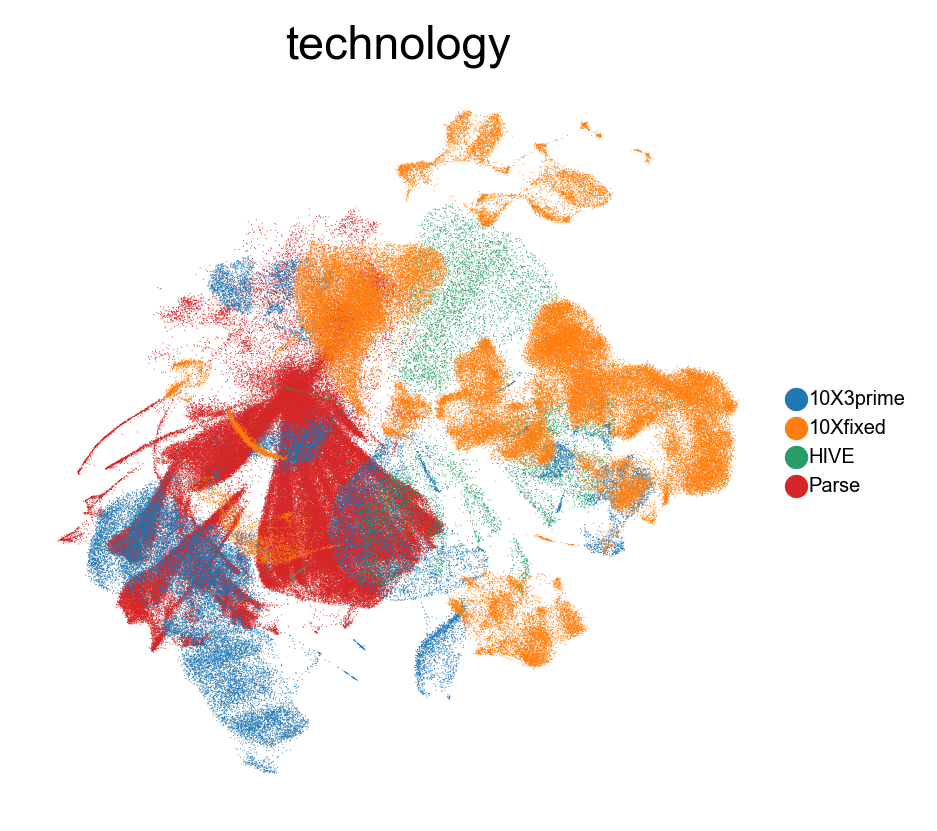

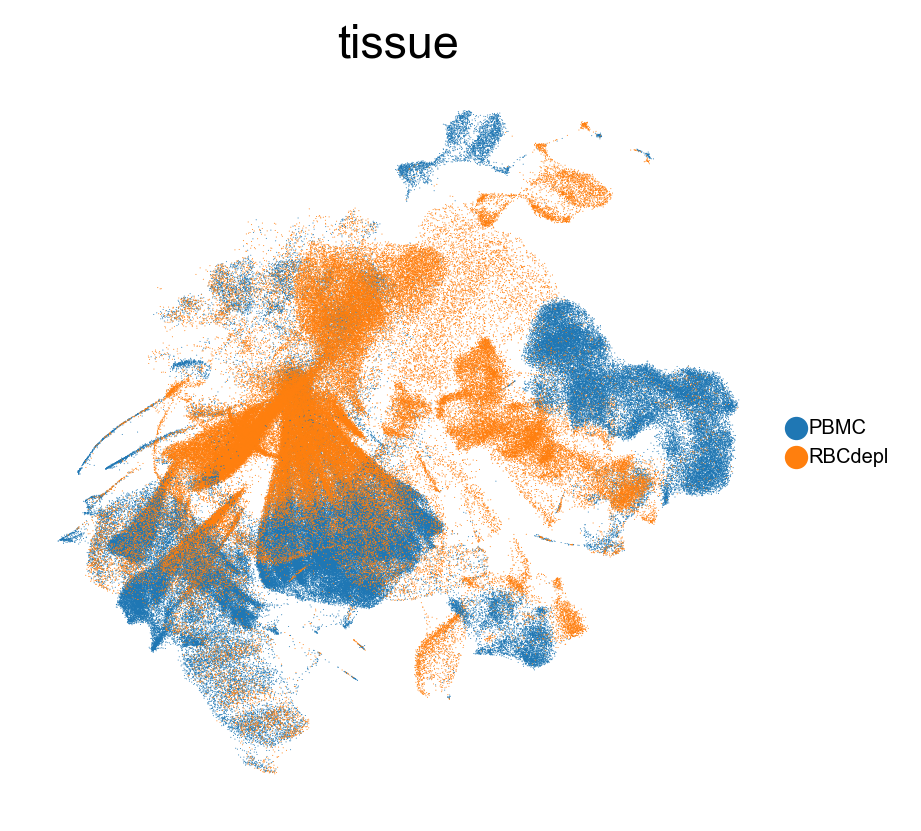

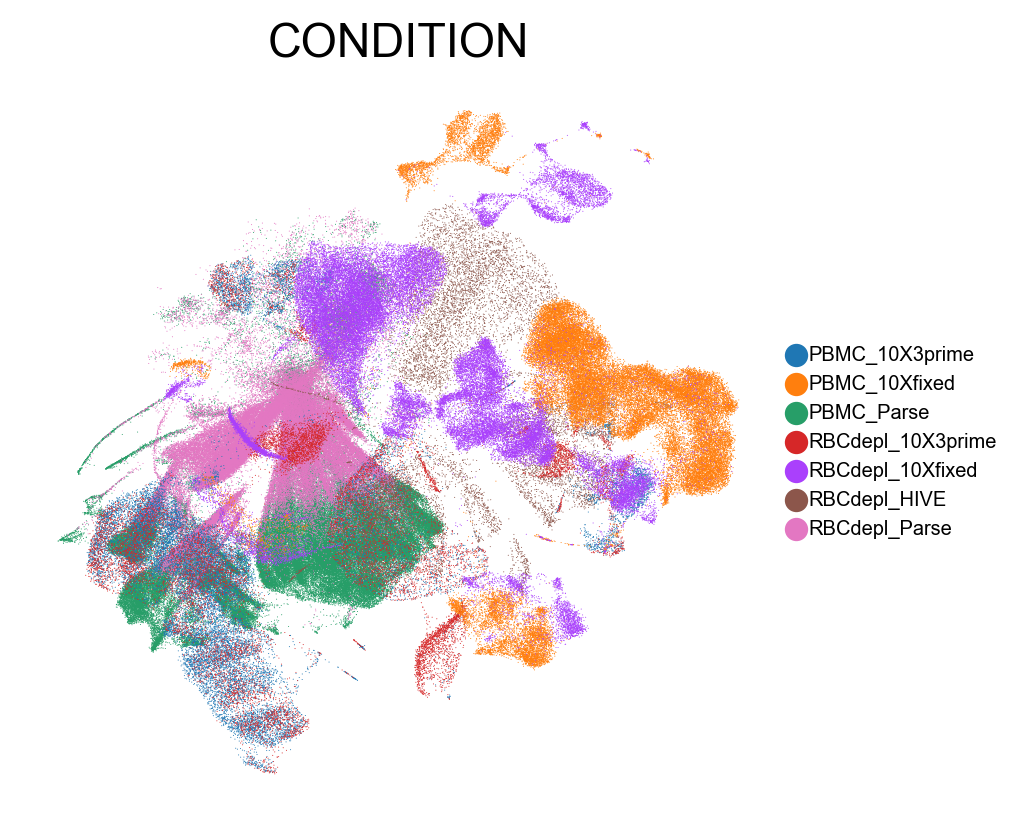

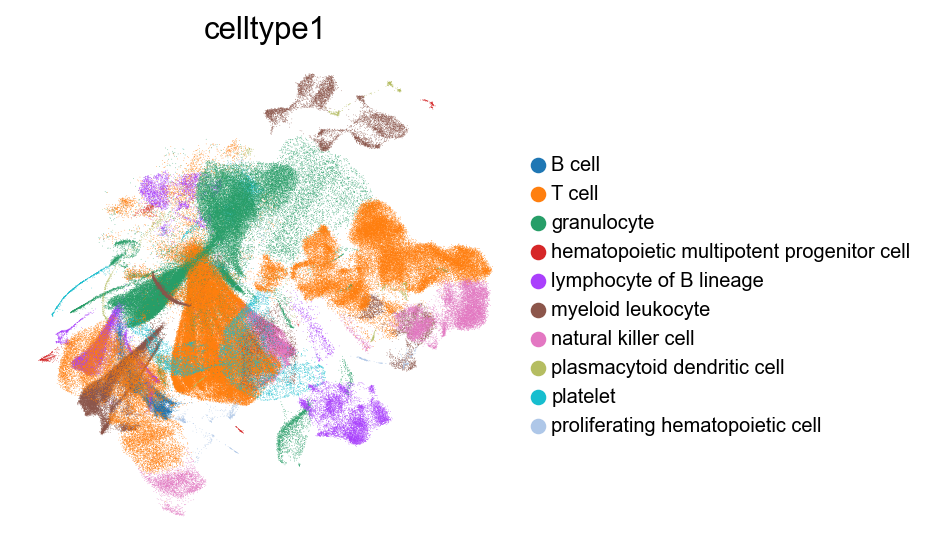

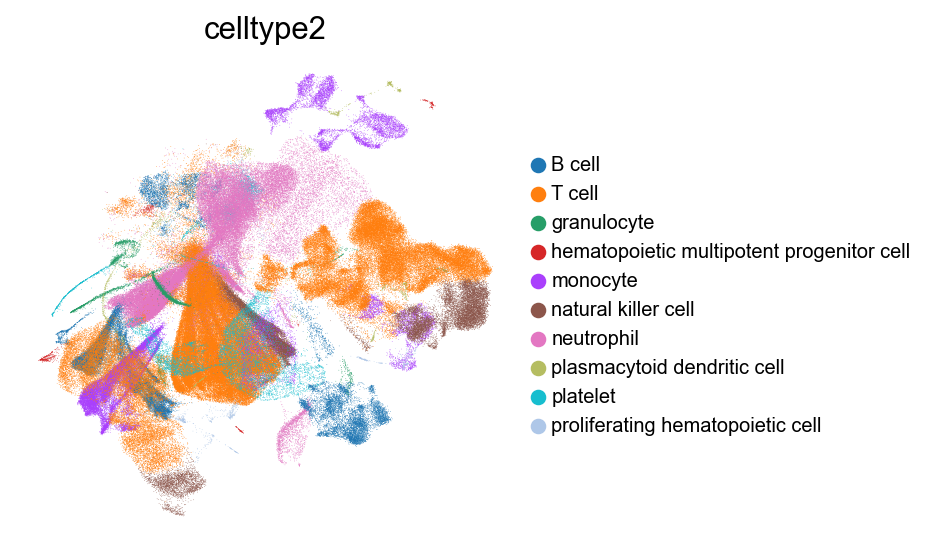

In [6]:
# TECHNOLOGY UMAP
sc.settings.set_figure_params(dpi=120)
sc.pl.umap(
    adata,
    color=["technology"],
    frameon=False,
    legend_fontsize=6,
)

# TISSUE UMAP
sc.settings.set_figure_params(dpi=120)
sc.pl.umap(
    adata,
    color=["tissue"],
    frameon=False,
    legend_fontsize=6,
)

# CONDITION UMAP
sc.settings.set_figure_params(dpi=120)
sc.pl.umap(
    adata,
    color=["CONDITION"],
    frameon=False,
    legend_fontsize=6,
)

# CELL TYPE UMAP
sc.settings.set_figure_params(dpi=80)
sc.pl.umap(
    adata,
    color=["celltype1"],
    frameon=False,
    legend_fontsize=9,
)

sc.pl.umap(
    adata,
    color=["celltype2"],
    frameon=False,
    legend_fontsize=9,
)
